# Neural Network for Stress Prediction

Surrogate model to predict stress from wing geometry parameters (`W1`, `W2`, `R`, `t`), trained on FEA simulation data. Architecture and hyperparameters are selected via cross-validation and compared against the GPR baseline.

## Imports

In [52]:
import time
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import joblib
import matplotlib.pyplot as plt
from torch import nn
from dataclasses import dataclass
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

## Constants

In [10]:
# Set a fixed random state for reproducibility across all random operations
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
# Set the path to the dataset
DATA_PATH = "../data/TrainingData_256.csv"
# Set device to run model on
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

In [11]:
# Check model is running on apple silicon
print(f"Using {DEVICE} device")

Using mps device


## Data Pre-Processing

### Load & Inspect Dataset

In [12]:
# Load the dataset into pandas dataframe
df = pd.read_csv(DATA_PATH)
# Print first 5 rows of the dataframe
df.head()

,W1,W2,R,t,MaxVonMisesStress_MPa
0,0.30,0.10000,0.030,0.01000,80.611312
1,0.50,0.12500,0.050,0.01500,44.253276
2,0.40,0.13750,0.040,0.01750,48.132708
3,0.60,0.11250,0.060,0.01250,45.352288
4,0.35,0.13125,0.065,0.01875,39.334132


In [5]:
# Convert to numpy array
X = df.drop('MaxVonMisesStress_MPa', axis=1).to_numpy()          
y = df['MaxVonMisesStress_MPa'].to_numpy()

### Train / Test Split

Hold out 20% as a test set — never touched during architecture search or training.

In [14]:
# Split the dataset into training and testing sets (80% train, 20% test) - Random state is set for reproducibility
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

### Scale data 

In [ ]:
# Scale the features and target variable using StandardScaler
@dataclass # A dataclass to hold the scaled data and scalers for features and target variable
class ScaledData:
    X_train: np.ndarray # Scaled training features
    X_test: np.ndarray # Scaled testing features
    y_train: np.ndarray # Scaled training target variable
    y_test: np.ndarray # Scaled testing target variable
    feature_scaler: StandardScaler # Scaler used for features
    target_scaler: StandardScaler # Scaler used for target variable

    # Static method to scale the training and testing data using StandardScaler
    @staticmethod
    def scale_data(X_train, X_test, y_train, y_test):
        feature_scaler = StandardScaler() # Scaler for features
        target_scaler = StandardScaler() # Scaler for target variable

        # Fit the feature scaler on the training features and transform both training and testing features
        return ScaledData(
            X_train=feature_scaler.fit_transform(X_train),
            X_test=feature_scaler.transform(X_test),
            y_train=target_scaler.fit_transform(y_train.reshape(-1, 1)).flatten(),
            y_test=target_scaler.transform(y_test.reshape(-1, 1)).flatten(),
            feature_scaler=feature_scaler,
            target_scaler=target_scaler,
        )

## Model Architecture & Hyperparameters

### Helper Functions

In [ ]:
# Function to build a multi-layer perceptron (MLP) model with specified parameters
def build_mlp(n_inputs=4, hidden_layers=(32, 32), activation='relu', dropout=0.0): # default values for parameters
    # Dictionary mapping activation function names to their corresponding PyTorch activation functions
    act = {
        'relu': nn.ReLU(),
        'ELU': nn.ELU(),
        'tanh': nn.Tanh(),
        'sine': nn.SiLU(),
        'sigmoid': nn.Sigmoid(),
        'soft_plus': nn.Softplus(),
    }
    
    # Check if the specified activation function is supported, if not raise a ValueError
    if activation not in act:
            raise ValueError(f"Unsupported activation function: {activation}")
    
    # Build the layers of the MLP based on the specified hidden layer sizes, activation function, and dropout rate
    # list to hold the layers of the MLP
    layers = []
    prev = n_inputs # number of input features
    # Loop through the specified hidden layer sizes and add the corresponding layers to the MLP
    for h in hidden_layers:
        # Add a linear layer with 'prev' input features and 'h' output features, followed by the specified activation function and dropout (if any)
        layers.append(nn.Linear(prev, h))
        layers.append(act[activation])
        if dropout > 0: # Add dropout layer if dropout rate is greater than 0
            layers.append(nn.Dropout(dropout))
        prev = h
    layers.append(nn.Linear(prev, 1))  # linear output for regression
    # Return the MLP model as a sequential container of layers
    return nn.Sequential(*layers)

In [33]:
# Function to train the MLP model on the training data and evaluate on the validation data
def train_model(model, X_tr, y_tr, X_val, y_val, lr=1e-3, optimiser='adam', loss_fn='mse', batch_size=32, weight_decay=0.0, max_epochs=100, patience=10): # default values for parameters
# Convert numpy arrays to PyTorch tensors (float32 is standard for NN)
    Xt = torch.tensor(X_tr, dtype=torch.float32)
    yt = torch.tensor(y_tr, dtype=torch.float32).view(-1, 1)
    Xv = torch.tensor(X_val, dtype=torch.float32)
    yv = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    # Initalise optimisers and loss function
    if optimiser == 'adam': # Use Adam optimizer with learning rate of 0.001
        optim = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimiser == 'sgd': # Use SGD optimizer with learning rate of 0.01 and momentum of 0.9
        optim = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimiser == 'rmsprop': # Use RMSprop optimizer with learning rate of 0.001 and alpha of 0.9
        optim = torch.optim.RMSprop(model.parameters(), lr=lr, alpha=0.9)
    elif optimiser == 'l-bfgs': # Use LBFGS optimizer with learning rate of 0.01 and max iterations of 20
        optim = torch.optim.LBFGS(model.parameters(), lr=lr, max_iter=20)
    else:
        raise ValueError(f"Unsupported optimiser: {optimiser}")
    
    loss_ft = {
        'mse': nn.MSELoss(), # Mean Squared Error loss function for regression
        'mae': nn.L1Loss(), # Mean Absolute Error loss function for regression
        'huber': nn.SmoothL1Loss(), # Huber loss function for regression (less sensitive to outliers than MSE)
        'neg_log_likelihood': nn.GaussianNLLLoss(), # Negative Log Likelihood loss function for regression (assumes Gaussian distribution of errors)
    }

    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True) # Create DataLoader for training data

    # Early-stopping bookkeeping
    best_val = float('inf')
    best_state = None
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': []}
 
    for epoch in range(max_epochs):
        # ---- Training pass: minibatch SGD over the training set ----
        model.train()
        train_losses = []
        for xb, yb in loader:
            optim.zero_grad()
            loss = loss_ft[loss_fn](model(xb), yb)
            loss.backward()
            optim.step()
            train_losses.append(loss.item())
 
        # ---- Validation pass: full-batch, no gradients ----
        model.eval()
        with torch.no_grad():
            val_loss = loss_ft[loss_fn](model(Xv), yv).item()
 
        history['train_loss'].append(float(np.mean(train_losses)))
        history['val_loss'].append(val_loss)
 
        # ---- Early stopping check (Goodfellow Ch.7 Alg. 7.1) ----
        if val_loss < best_val:
            best_val = val_loss
            # Deep-copy current weights as the new best
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break
 
    # Restore the best weights (not the final ones) before returning
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_val, epoch + 1


In [17]:
def evaluate(model, X_scaled, y_true_unscaled, target_scaler):
    """Compute regression metrics in ORIGINAL units (MPa).
 
    All reported numbers must be in physical units, not scaled space, so
    the prediction is inverse-transformed before computing errors.
    """
    model.eval()
    Xt = torch.tensor(X_scaled, dtype=torch.float32)
    with torch.no_grad():
        y_pred_scaled = model(Xt).numpy().flatten()
    # Inverse-transform back to MPa
    y_pred = target_scaler.inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    ).flatten()
 
    err = y_pred - y_true_unscaled
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    mape = float(np.mean(np.abs(err / y_true_unscaled)) * 100)
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true_unscaled - y_true_unscaled.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot
    return {'rmse': rmse, 'mae': mae, 'mape': mape, 'r2': r2,
            'y_pred': y_pred}

In [18]:
def cv_evaluate(X_train_raw, y_train_raw, build_kwargs, train_kwargs,
                k=5, seed=SEED, val_frac_in_fold=0.15):
    """k-fold cross-validation for one architecture/hyperparameter config.
 
    Crucially, scalers are refit INSIDE each fold to prevent leakage of
    validation-fold statistics into training. The training fold is further
    split to provide an early-stopping validation set distinct from the
    CV evaluation set.
 
    Args:
        X_train_raw, y_train_raw: UNscaled training data (N=204)
        build_kwargs: dict passed to build_mlp()
        train_kwargs: dict passed to train_model()
        k: number of CV folds (5 to match GPR, per Goodfellow Ch.5 / ISLP Ch.5)
        val_frac_in_fold: fraction of each fold's train set used for early stop
    Returns:
        dict with mape/rmse means and stds across folds, plus mean train time
    """
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    mapes, rmses, times, epochs = [], [], [], []
 
    for fold_idx, (tr_idx, eval_idx) in enumerate(kf.split(X_train_raw)):
        # Split the original (unscaled) training data into this fold's
        # train/eval sets - eval is what we report CV metrics on
        X_tr_raw = X_train_raw[tr_idx]
        y_tr_raw = y_train_raw[tr_idx]
        X_eval_raw = X_train_raw[eval_idx]
        y_eval_raw = y_train_raw[eval_idx]
 
        # Carve out an internal validation slice from this fold's train data
        # purely for early-stopping (NOT the same as the CV eval set)
        X_sub, X_es, y_sub, y_es = train_test_split(
            X_tr_raw, y_tr_raw,
            test_size=val_frac_in_fold, random_state=seed
        )
 
        # Fit scalers on this fold's training-only slice
        fs = StandardScaler().fit(X_sub)
        ts = StandardScaler().fit(y_sub.reshape(-1, 1))
 
        X_sub_s = fs.transform(X_sub)
        X_es_s = fs.transform(X_es)
        X_eval_s = fs.transform(X_eval_raw)
        y_sub_s = ts.transform(y_sub.reshape(-1, 1)).flatten()
        y_es_s = ts.transform(y_es.reshape(-1, 1)).flatten()
 
        # Build & train
        # Re-seed per fold so all configs get the same init pattern
        torch.manual_seed(seed + fold_idx)
        model = build_mlp(**build_kwargs)
 
        t0 = time.time()
        model, _, _, n_epochs = train_model(
            model, X_sub_s, y_sub_s, X_es_s, y_es_s, **train_kwargs
        )
        times.append(time.time() - t0)
        epochs.append(n_epochs)
 
        # Evaluate on the CV eval fold - in MPa
        m = evaluate(model, X_eval_s, y_eval_raw, ts)
        mapes.append(m['mape'])
        rmses.append(m['rmse'])
 
    return {
        'mape_mean': float(np.mean(mapes)), 'mape_std': float(np.std(mapes)),
        'rmse_mean': float(np.mean(rmses)), 'rmse_std': float(np.std(rmses)),
        'time_mean': float(np.mean(times)),
        'epochs_mean': float(np.mean(epochs)),
    }

In [27]:
def count_parameters(model):
    """Count trainable parameters - reported in depth/width experiment tables."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Systematic Exploration of Architectures & Hyperparameters

In [24]:
print("\n=== Experiment 1: Activation function ===")
exp1_rows = []
for act in ['relu', 'ELU', 'tanh', 'sine', 'sigmoid', 'soft_plus']:
    bk = {'hidden_layers': (32, 32), 'activation': act, 'dropout': 0.0}
    tk = {'optimiser': 'adam', 'lr': 1e-3,
          'batch_size': 32, 'max_epochs': 500, 'patience': 20}
    r = cv_evaluate(X_train_raw, y_train_raw, bk, tk)
    exp1_rows.append({'activation': act, **r})
    print(f"  {act:12s}  CV MAPE = {r['mape_mean']:.3f} ± {r['mape_std']:.3f} %"
          f"   time = {r['time_mean']:.2f} s")
exp1 = pd.DataFrame(exp1_rows)
exp1.to_csv('../results/exp1_activation.csv', index=False)
 
# Lock in winner for downstream experiments
BEST_ACT = exp1.sort_values('mape_mean').iloc[0]['activation']
print(f"  -> Best activation: {BEST_ACT}")


=== Experiment 1: Activation function ===
  relu          CV MAPE = 1.689 ± 0.198 %   time = 0.35 s
  ELU           CV MAPE = 1.831 ± 0.350 %   time = 0.32 s
  tanh          CV MAPE = 1.369 ± 0.479 %   time = 0.48 s
  sine          CV MAPE = 1.247 ± 0.117 %   time = 0.24 s
  sigmoid       CV MAPE = 3.466 ± 0.325 %   time = 0.29 s
  soft_plus     CV MAPE = 1.399 ± 0.286 %   time = 0.55 s
  -> Best activation: sine


In [28]:
print("\n=== Experiment 2: Depth ===")
exp2_rows = []
for depth in [1, 2, 3, 4]:
    bk = {'hidden_layers': (32,) * depth, 'activation': BEST_ACT, 'dropout': 0.0}
    tk = {'optimiser': 'adam', 'lr': 1e-3,
          'batch_size': 32, 'max_epochs': 500, 'patience': 20}
    r = cv_evaluate(X_train_raw, y_train_raw, bk, tk)
    n_params = count_parameters(build_mlp(**bk))
    exp2_rows.append({'depth': depth, 'n_params': n_params, **r})
    print(f"  depth={depth}  params={n_params:5d}  "
          f"CV MAPE = {r['mape_mean']:.3f} ± {r['mape_std']:.3f} %")
exp2 = pd.DataFrame(exp2_rows)
exp2.to_csv('../results/exp2_depth.csv', index=False)
 
BEST_DEPTH = int(exp2.sort_values('mape_mean').iloc[0]['depth'])
print(f"  -> Best depth: {BEST_DEPTH}")


=== Experiment 2: Depth ===
  depth=1  params=  193  CV MAPE = 1.661 ± 0.137 %
  depth=2  params= 1249  CV MAPE = 1.247 ± 0.117 %
  depth=3  params= 2305  CV MAPE = 0.866 ± 0.131 %
  depth=4  params= 3361  CV MAPE = 0.766 ± 0.185 %
  -> Best depth: 4


In [30]:
print("\n=== Experiment 3: Width ===")
exp3_rows = []
for width in [8, 16, 32, 64, 128]:
    bk = {'hidden_layers': (width,) * BEST_DEPTH,
          'activation': BEST_ACT, 'dropout': 0.0}
    tk = {'optimiser': 'adam', 'lr': 1e-3,
          'batch_size': 32, 'max_epochs': 500, 'patience': 20}
    r = cv_evaluate(X_train_raw, y_train_raw, bk, tk)
    n_params = count_parameters(build_mlp(**bk))
    exp3_rows.append({'width': width, 'n_params': n_params, **r})
    print(f"  width={width:3d}  params={n_params:5d}  "
          f"CV MAPE = {r['mape_mean']:.3f} ± {r['mape_std']:.3f} %")
exp3 = pd.DataFrame(exp3_rows)
exp3.to_csv('../results/exp3_width.csv', index=False)
 
BEST_WIDTH = int(exp3.sort_values('mape_mean').iloc[0]['width'])
print(f"  -> Best width: {BEST_WIDTH}")


=== Experiment 3: Width ===
  width=  8  params=  265  CV MAPE = 1.951 ± 0.968 %
  width= 16  params=  913  CV MAPE = 0.998 ± 0.275 %
  width= 32  params= 3361  CV MAPE = 0.766 ± 0.185 %
  width= 64  params=12865  CV MAPE = 0.696 ± 0.141 %
  width=128  params=50305  CV MAPE = 0.627 ± 0.085 %
  -> Best width: 128


In [34]:
print("\n=== Experiment 4: Regularisation ===")
reg_configs = [
    ('none',           {'dropout': 0.0}, {'weight_decay': 0.0}),
    ('L2_1e-4',        {'dropout': 0.0}, {'weight_decay': 1e-4}),
    ('L2_1e-3',        {'dropout': 0.0}, {'weight_decay': 1e-3}),
    ('L2_1e-2',        {'dropout': 0.0}, {'weight_decay': 1e-2}),
    ('Dropout_0.1',    {'dropout': 0.1}, {'weight_decay': 0.0}),
    ('Dropout_0.2',    {'dropout': 0.2}, {'weight_decay': 0.0}),
    ('L2_1e-3+Drop_0.1', {'dropout': 0.1}, {'weight_decay': 1e-3}),
]
exp4_rows = []
for name, build_extra, train_extra in reg_configs:
    bk = {'hidden_layers': (BEST_WIDTH,) * BEST_DEPTH,
          'activation': BEST_ACT, **build_extra}
    tk = {'optimiser': 'adam', 'lr': 1e-3,
          'batch_size': 32, 'max_epochs': 500, 'patience': 20, **train_extra}
    r = cv_evaluate(X_train_raw, y_train_raw, bk, tk)
    exp4_rows.append({'scheme': name, **r})
    print(f"  {name:20s}  CV MAPE = {r['mape_mean']:.3f} ± {r['mape_std']:.3f} %")
exp4 = pd.DataFrame(exp4_rows)
exp4.to_csv('../results/exp4_regularisation.csv', index=False)
 
BEST_REG = exp4.sort_values('mape_mean').iloc[0]
BEST_DROPOUT = float(reg_configs[exp4['mape_mean'].idxmin()][1]['dropout'])
BEST_WD = float(reg_configs[exp4['mape_mean'].idxmin()][2]['weight_decay'])
print(f"  -> Best regularisation: {BEST_REG['scheme']} "
      f"(dropout={BEST_DROPOUT}, wd={BEST_WD})")


=== Experiment 4: Regularisation ===
  none                  CV MAPE = 0.627 ± 0.085 %
  L2_1e-4               CV MAPE = 0.627 ± 0.085 %
  L2_1e-3               CV MAPE = 0.627 ± 0.085 %
  L2_1e-2               CV MAPE = 0.627 ± 0.085 %
  Dropout_0.1           CV MAPE = 1.124 ± 0.195 %
  Dropout_0.2           CV MAPE = 1.482 ± 0.315 %
  L2_1e-3+Drop_0.1      CV MAPE = 1.124 ± 0.195 %
  -> Best regularisation: none (dropout=0.0, wd=0.0)


In [36]:
print("\n=== Experiment 5: Optimiser ===")
exp5_rows = []
for opt in ['adam', 'sgd', 'rmsprop']:
    # Sweep 3 LRs per optimiser, keep the best
    best_for_opt = None
    for lr in [1e-4, 1e-3, 1e-2]:
        bk = {'hidden_layers': (BEST_WIDTH,) * BEST_DEPTH,
              'activation': BEST_ACT, 'dropout': BEST_DROPOUT}
        tk = {'optimiser': opt, 'lr': lr, 'weight_decay': BEST_WD,
              'batch_size': 32, 'max_epochs': 500, 'patience': 20}
        r = cv_evaluate(X_train_raw, y_train_raw, bk, tk)
        if best_for_opt is None or r['mape_mean'] < best_for_opt['mape_mean']:
            best_for_opt = {'optimiser': opt, 'best_lr': lr, **r}
    exp5_rows.append(best_for_opt)
    print(f"  {opt:8s}  best lr={best_for_opt['best_lr']:.0e}  "
          f"CV MAPE = {best_for_opt['mape_mean']:.3f} ± "
          f"{best_for_opt['mape_std']:.3f} %")
exp5 = pd.DataFrame(exp5_rows)
exp5.to_csv('../results/exp5_optimiser.csv', index=False)
 
BEST_OPT = exp5.sort_values('mape_mean').iloc[0]['optimiser']
print(f"  -> Best optimiser: {BEST_OPT}")


=== Experiment 5: Optimiser ===
  adam      best lr=1e-03  CV MAPE = 0.627 ± 0.085 %
  sgd       best lr=1e-02  CV MAPE = 1.011 ± 0.135 %
  rmsprop   best lr=1e-04  CV MAPE = 1.153 ± 0.092 %
  -> Best optimiser: adam


In [41]:
print("\n=== Experiment 6: Learning rate ===")
exp6_rows = []
for lr in [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]:
    bk = {'hidden_layers': (BEST_WIDTH,) * BEST_DEPTH,
          'activation': BEST_ACT, 'dropout': BEST_DROPOUT}
    tk = {'optimiser': BEST_OPT, 'lr': lr, 'weight_decay': BEST_WD,
          'batch_size': 32, 'max_epochs': 500, 'patience': 20}
    r = cv_evaluate(X_train_raw, y_train_raw, bk, tk)
    exp6_rows.append({'lr': lr, **r})
    print(f"  lr={lr:.0e}  CV MAPE = {r['mape_mean']:.3f} ± {r['mape_std']:.3f} %")
exp6 = pd.DataFrame(exp6_rows)
exp6.to_csv('../results/exp6_lr.csv', index=False)
 
BEST_LR = float(exp6.sort_values('mape_mean').iloc[0]['lr'])
print(f"  -> Best learning rate: {BEST_LR}")


=== Experiment 6: Learning rate ===
  lr=1e-04  CV MAPE = 0.915 ± 0.105 %
  lr=3e-04  CV MAPE = 0.729 ± 0.158 %
  lr=1e-03  CV MAPE = 0.627 ± 0.085 %
  lr=3e-03  CV MAPE = 0.705 ± 0.155 %
  lr=1e-02  CV MAPE = 0.923 ± 0.133 %
  -> Best learning rate: 0.001


In [44]:
print("\n=== Experiment 7: Batch size ===")
exp7_rows = []
for bs in [16, 32, 64, len(X_train_raw)]:  # full-batch = 204
    bk = {'hidden_layers': (BEST_WIDTH,) * BEST_DEPTH,
          'activation': BEST_ACT, 'dropout': BEST_DROPOUT}
    tk = {'optimiser': BEST_OPT, 'lr': BEST_LR, 'weight_decay': BEST_WD,
          'batch_size': bs, 'max_epochs': 500, 'patience': 20}
    r = cv_evaluate(X_train_raw, y_train_raw, bk, tk)
    exp7_rows.append({'batch_size': bs, **r})
    print(f"  bs={bs:4d}  CV MAPE = {r['mape_mean']:.3f} ± {r['mape_std']:.3f} %"
          f"   time = {r['time_mean']:.2f} s")
exp7 = pd.DataFrame(exp7_rows)
exp7.to_csv('../results/exp7_batch.csv', index=False)
 
BEST_BS = int(exp7.sort_values('mape_mean').iloc[0]['batch_size'])
print(f"  -> Best batch size: {BEST_BS}")


=== Experiment 7: Batch size ===
  bs=  16  CV MAPE = 0.603 ± 0.136 %   time = 0.68 s
  bs=  32  CV MAPE = 0.627 ± 0.085 %   time = 0.70 s
  bs=  64  CV MAPE = 0.950 ± 0.174 %   time = 0.41 s
  bs= 204  CV MAPE = 0.718 ± 0.444 %   time = 4.41 s
  -> Best batch size: 16


In [46]:
print("\n=== Experiment 8: Training set size scan ===")
exp8_rows = []
for n in [20, 50, 100, 150, 204]:
    # Take the first n rows of the (already-shuffled) training data
    Xn = X_train_raw[:n]; yn = y_train_raw[:n]
 
    # Set up scalers and split off ~15% for early stopping (or 1 sample at n=20)
    val_frac = max(0.15, 3 / n)  # ensure at least 3 ES samples
    X_sub, X_es, y_sub, y_es = train_test_split(
        Xn, yn, test_size=val_frac, random_state=SEED)
    fs = StandardScaler().fit(X_sub)
    ts = StandardScaler().fit(y_sub.reshape(-1, 1))
    X_sub_s = fs.transform(X_sub); X_es_s = fs.transform(X_es)
    y_sub_s = ts.transform(y_sub.reshape(-1, 1)).flatten()
    y_es_s = ts.transform(y_es.reshape(-1, 1)).flatten()
    X_test_s = fs.transform(X_test_raw)
 
    torch.manual_seed(SEED)
    model = build_mlp(hidden_layers=(BEST_WIDTH,) * BEST_DEPTH,
                      activation=BEST_ACT, dropout=BEST_DROPOUT)
    t0 = time.time()
    model, _, _, n_epochs = train_model(
        model, X_sub_s, y_sub_s, X_es_s, y_es_s,
        optimiser=BEST_OPT, lr=BEST_LR, weight_decay=BEST_WD,
        batch_size=min(BEST_BS, n - len(X_es)),
        max_epochs=500, patience=20)
    train_t = time.time() - t0
 
    # Evaluate on the SAME held-out test set used everywhere else
    m = evaluate(model, X_test_s, y_test_raw, ts)
    exp8_rows.append({'n_samples': n, 'test_rmse': m['rmse'],
                      'test_mape': m['mape'], 'train_time': train_t,
                      'epochs': n_epochs})
    print(f"  N={n:3d}  RMSE={m['rmse']:.3f} MPa  MAPE={m['mape']:.3f}%  "
          f"time={train_t:.2f}s  epochs={n_epochs}")
exp8 = pd.DataFrame(exp8_rows)
exp8.to_csv('../results/exp8_n_samples.csv', index=False)


=== Experiment 8: Training set size scan ===
  N= 20  RMSE=6.735 MPa  MAPE=6.439%  time=0.12s  epochs=41
  N= 50  RMSE=1.390 MPa  MAPE=1.114%  time=0.31s  epochs=100
  N=100  RMSE=0.671 MPa  MAPE=0.903%  time=0.77s  epochs=81
  N=150  RMSE=0.389 MPa  MAPE=0.358%  time=0.79s  epochs=143
  N=204  RMSE=0.307 MPa  MAPE=0.418%  time=1.53s  epochs=181


## Final Model Training & Evaluation on Test Set

In [48]:
print("\n=== Final model training ===")
 
# Apply the original 80:20 split's scaling and split off internal val for ES
X_sub_raw, X_val_raw, y_sub_raw, y_val_raw = train_test_split(
    X_train_raw, y_train_raw, test_size=0.15, random_state=SEED)
 
final_fs = StandardScaler().fit(X_sub_raw)
final_ts = StandardScaler().fit(y_sub_raw.reshape(-1, 1))
 
X_sub_s = final_fs.transform(X_sub_raw)
X_val_s = final_fs.transform(X_val_raw)
y_sub_s = final_ts.transform(y_sub_raw.reshape(-1, 1)).flatten()
y_val_s = final_ts.transform(y_val_raw.reshape(-1, 1)).flatten()
X_test_s_final = final_fs.transform(X_test_raw)
 
# Build and train the final model with all the best hyperparameters
torch.manual_seed(SEED)
final_model = build_mlp(
    hidden_layers=(BEST_WIDTH,) * BEST_DEPTH,
    activation=BEST_ACT,
    dropout=BEST_DROPOUT,
)
print(f"Architecture: {BEST_DEPTH} layers x {BEST_WIDTH} units, "
      f"act={BEST_ACT}, dropout={BEST_DROPOUT}, "
      f"params={count_parameters(final_model)}")
 
t0 = time.time()
final_model, history, best_val, n_epochs = train_model(
    final_model, X_sub_s, y_sub_s, X_val_s, y_val_s,
    optimiser=BEST_OPT, lr=BEST_LR, weight_decay=BEST_WD,
    batch_size=BEST_BS, max_epochs=500, patience=30)
train_time = time.time() - t0
print(f"Trained in {n_epochs} epochs ({train_time:.2f} s)")


=== Final model training ===
Architecture: 4 layers x 128 units, act=sine, dropout=0.0, params=50305
Trained in 191 epochs (1.50 s)


In [49]:
print("\n=== Final test set evaluation ===")
test_metrics = evaluate(final_model, X_test_s_final, y_test_raw, final_ts)
print(f"  Test RMSE = {test_metrics['rmse']:.4f} MPa")
print(f"  Test MAE  = {test_metrics['mae']:.4f} MPa")
print(f"  Test MAPE = {test_metrics['mape']:.4f} %")
print(f"  Test R^2  = {test_metrics['r2']:.5f}")
 
# --- Learning curve figure (train + val loss vs epoch) ---
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(history['train_loss'], label='Training loss')
ax.plot(history['val_loss'], label='Validation loss')
ax.axvline(np.argmin(history['val_loss']), color='k', ls='--', alpha=0.5,
           label=f'Best epoch ({np.argmin(history["val_loss"])})')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled units)')
ax.set_title('Learning curve - final NN')
ax.legend(); ax.grid(alpha=0.3); ax.set_yscale('log')
plt.tight_layout(); plt.savefig('../figures/fig_learning_curve.png', dpi=300); plt.close()
 
# --- Parity plot (predicted vs true on test set) - mirrors GPR Fig 4 ---
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test_raw, test_metrics['y_pred'],
           alpha=0.7, edgecolor='k', linewidth=0.5)
lims = [min(y_test_raw.min(), test_metrics['y_pred'].min()),
        max(y_test_raw.max(), test_metrics['y_pred'].max())]
ax.plot(lims, lims, 'r--', label='Ideal Fit')
ax.set_xlabel('True σ_max (MPa)'); ax.set_ylabel('Predicted σ_max (MPa)')
ax.set_title(f'NN parity plot (R² = {test_metrics["r2"]:.4f})')
ax.legend(); ax.grid(alpha=0.3); ax.set_aspect('equal')
plt.tight_layout(); plt.savefig('../figures/fig_nn_parity.png', dpi=300); plt.close()


=== Final test set evaluation ===
  Test RMSE = 0.3065 MPa
  Test MAE  = 0.2029 MPa
  Test MAPE = 0.4177 %
  Test R^2  = 0.99937


## Saved Final Model

In [ ]:
models_dir = Path('../models'); models_dir.mkdir(exist_ok=True)
results_dir = Path('../results'); results_dir.mkdir(exist_ok=True)
torch.save(final_model.state_dict(), models_dir / 'nn_surrogate.pt')
joblib.dump({'feature_scaler': final_fs, 'target_scaler': final_ts,
             'arch': {'hidden_layers': (BEST_WIDTH,) * BEST_DEPTH,
                      'activation': BEST_ACT, 'dropout': BEST_DROPOUT}},
            models_dir / 'nn_scalers.joblib')
# Also dump the metrics dict for the write-up
pd.DataFrame([{
    'rmse_mpa': test_metrics['rmse'],
    'mae_mpa': test_metrics['mae'],
    'mape_pct': test_metrics['mape'],
    'r2': test_metrics['r2'],
    'train_time_s': train_time,
    'epochs': n_epochs,
}]).to_csv(results_dir / 'final_metrics.csv', index=False)

print(f"\nModel saved to {models_dir.resolve()}")
print(f"Metrics saved to {results_dir.resolve()}")
print("Done.")

### Visualisations

In [54]:
# ---- Common plotting style for all visualisations ----
# One place to tweak so every report figure looks consistent.
import matplotlib as mpl
from matplotlib import gridspec
from matplotlib.colors import TwoSlopeNorm

mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'legend.frameon': False,
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# Colour palette (colour-blind friendly, from Wong 2011)
C_PRIMARY   = '#0072B2'  # blue  - NN / predictions
C_SECONDARY = '#D55E00'  # orange - validation / residuals
C_ACCENT    = '#009E73'  # green - highlights / ideal
C_NEUTRAL   = '#56B4E9'  # light blue
C_GREY      = '#555555'

# Units / labels used in multiple plots
FEATURE_LABELS = {
    0: r'$W_1$ (m)',
    1: r'$W_2$ (m)',
    2: r'$R$ (m)',
    3: r'$t$ (m)',
}
FEATURE_NAMES = ['W1', 'W2', 'R', 't']

In [55]:
# Quick LR-curve plot (the Goodfellow U-shape) - cheap and looks good in report
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.errorbar(exp6['lr'], exp6['mape_mean'], yerr=exp6['mape_std'],
            marker='o', capsize=4)
ax.set_xscale('log'); ax.set_xlabel('Learning rate')
ax.set_ylabel('CV MAPE (%)'); ax.set_title('Learning rate sensitivity')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('../figures/fig_lr_sweep.png', dpi=300); plt.close()

#### Loss Curves

Training and validation loss over epochs for the best architecture. Verify convergence and check for overfitting.

/var/folders/lq/1f0d05w114x6x06k0hn90f0c0000gn/T/ipykernel_64917/1289079791.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


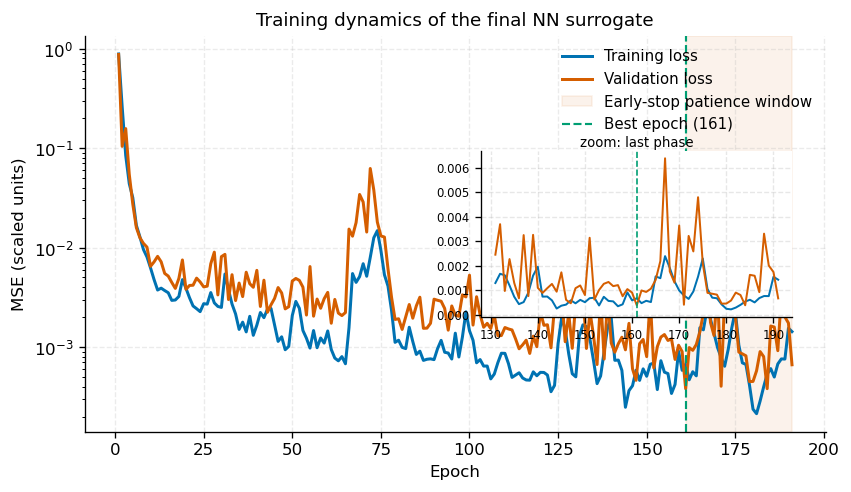

In [56]:
# ---- Figure: Training dynamics (loss curves + early-stop zoom inset) ----
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

train_losses = np.array(history['train_loss'])
val_losses = np.array(history['val_loss'])
best_epoch = int(np.argmin(val_losses))
stop_epoch = len(val_losses) - 1
epochs = np.arange(1, len(val_losses) + 1)

fig, ax = plt.subplots(figsize=(7.2, 4.2))

ax.plot(epochs, train_losses, color=C_PRIMARY, lw=1.8, label='Training loss')
ax.plot(epochs, val_losses, color=C_SECONDARY, lw=1.8, label='Validation loss')

# Shade the "patience" window (no-improvement streak that triggered early stop)
ax.axvspan(best_epoch + 1, stop_epoch + 1, color=C_SECONDARY,
           alpha=0.08, label='Early-stop patience window')
ax.axvline(best_epoch + 1, color=C_ACCENT, ls='--', lw=1.3,
           label=f'Best epoch ({best_epoch + 1})')

ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (scaled units)')
ax.set_yscale('log')
ax.set_title('Training dynamics of the final NN surrogate')
ax.legend(loc='upper right', fontsize=9)

# Zoom inset: last ~60 epochs, linear scale, to show how flat val gets
inset = inset_axes(ax, width='42%', height='42%', loc='center right',
                   borderpad=2.0)
zoom_start = max(0, best_epoch - 30)
inset.plot(epochs[zoom_start:], train_losses[zoom_start:],
           color=C_PRIMARY, lw=1.2)
inset.plot(epochs[zoom_start:], val_losses[zoom_start:],
           color=C_SECONDARY, lw=1.2)
inset.axvline(best_epoch + 1, color=C_ACCENT, ls='--', lw=1.0)
inset.set_title('zoom: last phase', fontsize=8, pad=2)
inset.tick_params(labelsize=7)
inset.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig_loss_curves.png')
plt.show()

#### Architecture Comparison: Predicted vs True

Scatter plot of predicted vs true stress for each candidate architecture. The dashed red line is the ideal fit.

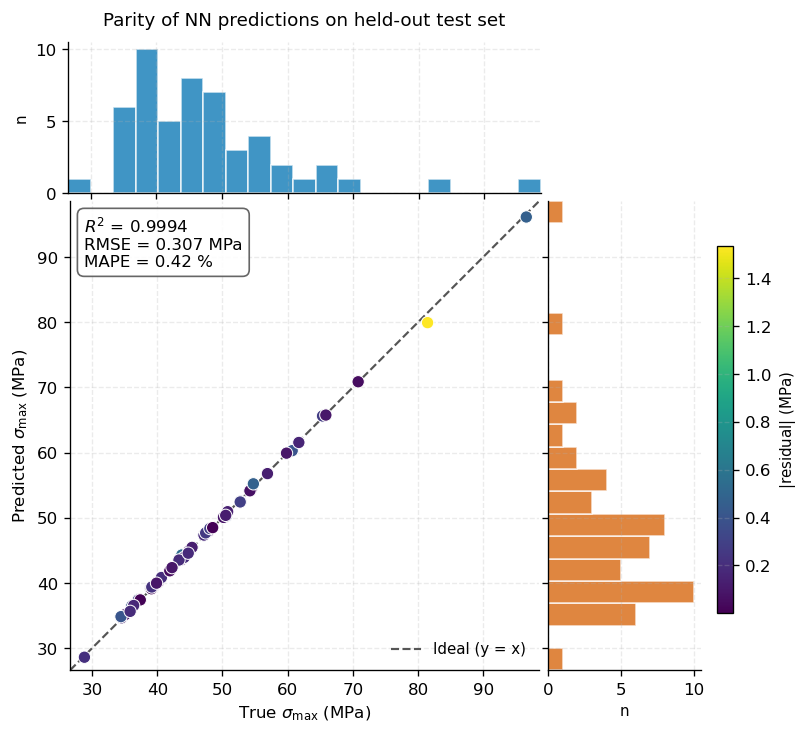

In [57]:
# ---- Figure: Parity plot with marginal histograms, coloured by |residual| ----
# A "joint plot" built from scratch using gridspec - main scatter is the parity,
# top/right panels show how true vs predicted stresses are distributed.
y_true = y_test_raw
y_pred = test_metrics['y_pred']
resid = y_pred - y_true
abs_resid = np.abs(resid)

fig = plt.figure(figsize=(6.8, 6.8))
gs = gridspec.GridSpec(4, 4, hspace=0.05, wspace=0.05)
ax_main = fig.add_subplot(gs[1:, :3])
ax_top = fig.add_subplot(gs[0, :3], sharex=ax_main)
ax_right = fig.add_subplot(gs[1:, 3], sharey=ax_main)

# Main parity scatter, size/colour scaled by absolute residual in MPa
sc = ax_main.scatter(y_true, y_pred, c=abs_resid, cmap='viridis',
                     s=55, edgecolor='white', linewidth=0.6, zorder=3)
lims = [min(y_true.min(), y_pred.min()) - 2,
        max(y_true.max(), y_pred.max()) + 2]
ax_main.plot(lims, lims, ls='--', lw=1.3, color=C_GREY,
             label='Ideal (y = x)', zorder=2)
ax_main.set_xlim(lims); ax_main.set_ylim(lims)
ax_main.set_aspect('equal')
ax_main.set_xlabel(r'True $\sigma_{\max}$ (MPa)')
ax_main.set_ylabel(r'Predicted $\sigma_{\max}$ (MPa)')

# Metric annotation box
txt = (f"$R^2$ = {test_metrics['r2']:.4f}\n"
       f"RMSE = {test_metrics['rmse']:.3f} MPa\n"
       f"MAPE = {test_metrics['mape']:.2f} %")
ax_main.text(0.03, 0.97, txt, transform=ax_main.transAxes,
             va='top', ha='left', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.4',
                       facecolor='white', edgecolor=C_GREY, alpha=0.9))
ax_main.legend(loc='lower right', fontsize=9)

# Marginal histograms
bins = np.linspace(lims[0], lims[1], 22)
ax_top.hist(y_true, bins=bins, color=C_PRIMARY, alpha=0.75, edgecolor='white')
ax_top.set_ylabel('n', fontsize=9)
ax_top.tick_params(axis='x', labelbottom=False)
ax_top.set_title('Parity of NN predictions on held-out test set', pad=10)

ax_right.hist(y_pred, bins=bins, orientation='horizontal',
              color=C_SECONDARY, alpha=0.75, edgecolor='white')
ax_right.set_xlabel('n', fontsize=9)
ax_right.tick_params(axis='y', labelleft=False)

# Colourbar for residuals
cbar_ax = fig.add_axes([0.92, 0.18, 0.02, 0.45])
cb = fig.colorbar(sc, cax=cbar_ax)
cb.set_label(r'$|$residual$|$ (MPa)', fontsize=9)

plt.savefig('../figures/fig_parity.png')
plt.show()

#### Residual Analysis

Residuals (predicted − true) plotted against true stress and against each input feature to diagnose systematic bias.

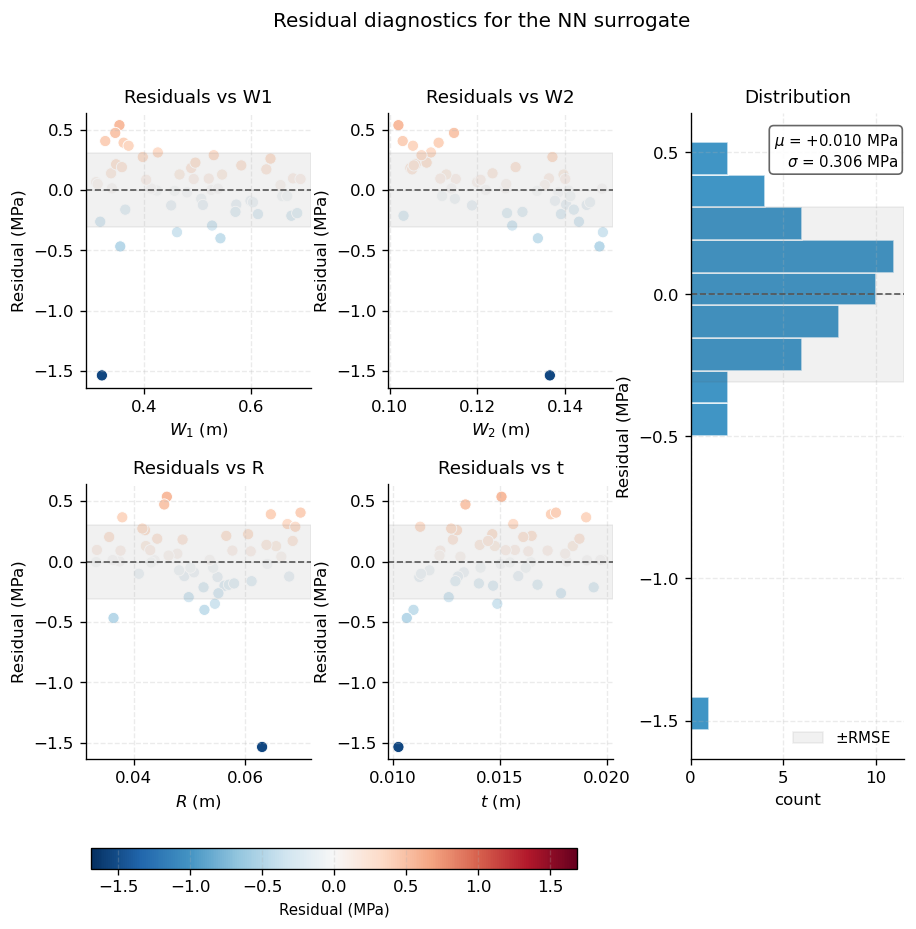

In [58]:
# ---- Figure: Residuals vs each input feature + residual distribution ----
# If the NN has any systematic bias across the design space it will show up as a
# slope/curve in one of these panels.  Flat = good.
resid = test_metrics['y_pred'] - y_test_raw          # MPa
rmax = float(np.max(np.abs(resid))) * 1.1
norm = TwoSlopeNorm(vmin=-rmax, vcenter=0, vmax=rmax)

fig = plt.figure(figsize=(8.8, 7.0))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.95],
                       hspace=0.35, wspace=0.35)

# 4 residual-vs-input panels (2x2 in the left block)
axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]

for i, ax in enumerate(axes):
    sc = ax.scatter(X_test_raw[:, i], resid, c=resid, cmap='RdBu_r',
                    norm=norm, s=45, edgecolor='white', linewidth=0.5)
    ax.axhline(0, color=C_GREY, lw=1, ls='--')
    # +/- RMSE band for visual scale
    ax.axhspan(-test_metrics['rmse'], test_metrics['rmse'],
               color=C_GREY, alpha=0.08)
    ax.set_xlabel(FEATURE_LABELS[i])
    ax.set_ylabel('Residual (MPa)')
    ax.set_title(f'Residuals vs {FEATURE_NAMES[i]}')

# Residual distribution panel (right column, spans both rows)
ax_hist = fig.add_subplot(gs[:, 2])
ax_hist.hist(resid, bins=18, color=C_PRIMARY, alpha=0.75,
             edgecolor='white', orientation='horizontal')
ax_hist.axhline(0, color=C_GREY, lw=1, ls='--')
ax_hist.axhspan(-test_metrics['rmse'], test_metrics['rmse'],
                color=C_GREY, alpha=0.08, label=r'$\pm$RMSE')
# Mean/std annotation
mu, sd = float(np.mean(resid)), float(np.std(resid))
ax_hist.text(0.97, 0.97,
             f'$\\mu$ = {mu:+.3f} MPa\n$\\sigma$ = {sd:.3f} MPa',
             transform=ax_hist.transAxes, va='top', ha='right',
             fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3',
                       facecolor='white', edgecolor=C_GREY, alpha=0.9))
ax_hist.set_xlabel('count')
ax_hist.set_ylabel('Residual (MPa)')
ax_hist.set_title('Distribution')
ax_hist.legend(loc='lower right', fontsize=9)

# Shared colour-bar under the 2x2 grid
cbar_ax = fig.add_axes([0.13, -0.02, 0.46, 0.025])
cb = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal')
cb.set_label('Residual (MPa)', fontsize=9)

fig.suptitle('Residual diagnostics for the NN surrogate',
             fontsize=12, y=1.00)
plt.savefig('../figures/fig_residuals.png')
plt.show()

#### Prediction Surface (W1 vs W2)

3D surface of predicted stress as `W1` and `W2` vary, with `R` and `t` held at their training-set means. Black points show training observations projected onto the surface.

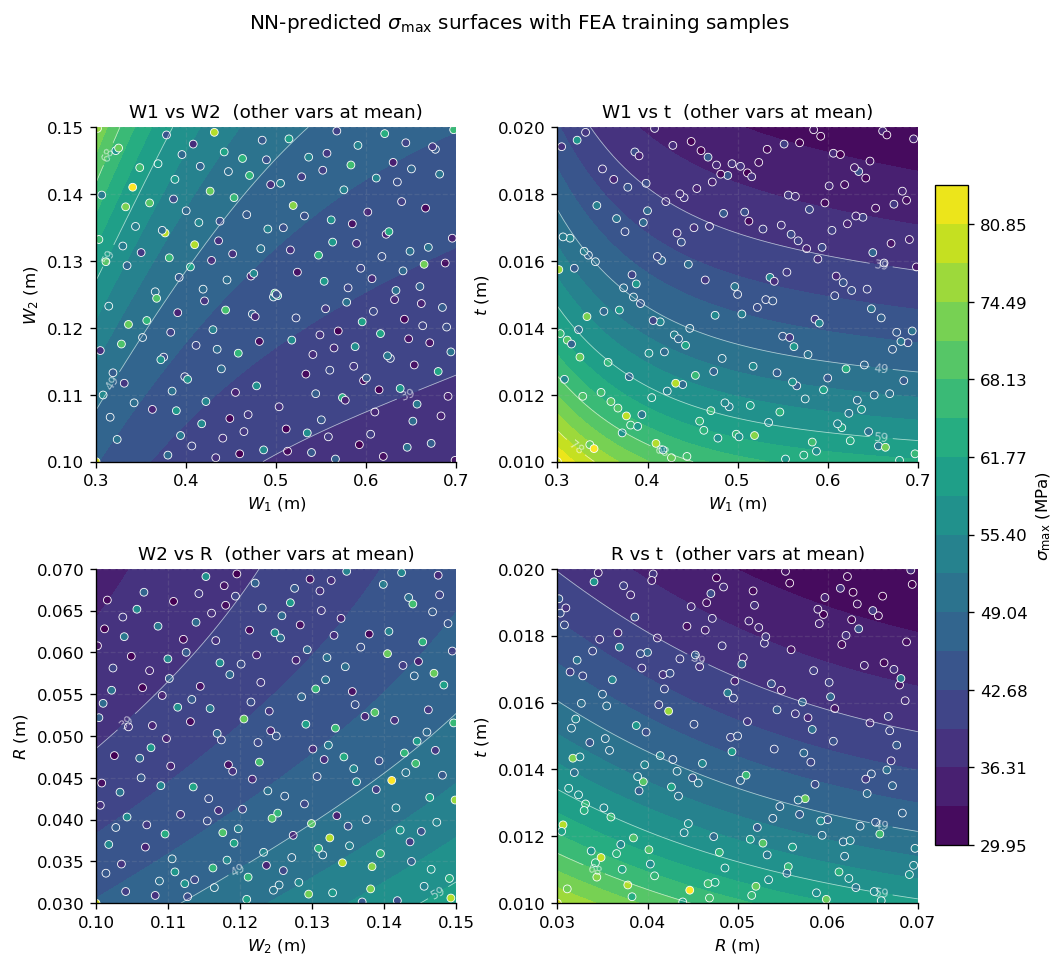

In [59]:
# ---- Figure: NN-predicted stress surfaces over pairs of design variables ----
# For each of 4 variable pairs we sweep a 60x60 grid, hold the other two at their
# training-set mean, push through the trained NN, and contour the result.
# FEA training data is overlaid as dots coloured by their true stress - gives a
# visual "does the surrogate agree with FEA" check.
PAIRS = [(0, 1), (0, 3), (1, 2), (2, 3)]   # (W1,W2), (W1,t), (W2,R), (R,t)
BOUNDS = np.array([[0.30, 0.70],            # W1
                   [0.10, 0.15],            # W2
                   [0.03, 0.07],            # R
                   [0.01, 0.02]])           # t
x_mean = X_train_raw.mean(axis=0)
GRID_N = 60

# Pre-compute all four surfaces on a shared colour scale
surfaces = []
for (i, j) in PAIRS:
    xi = np.linspace(*BOUNDS[i], GRID_N)
    xj = np.linspace(*BOUNDS[j], GRID_N)
    XI, XJ = np.meshgrid(xi, xj)
    grid = np.tile(x_mean, (GRID_N * GRID_N, 1))
    grid[:, i] = XI.ravel()
    grid[:, j] = XJ.ravel()
    grid_s = final_fs.transform(grid)
    final_model.eval()
    with torch.no_grad():
        pred_s = final_model(torch.tensor(grid_s,
                                          dtype=torch.float32)).numpy().ravel()
    pred = final_ts.inverse_transform(pred_s.reshape(-1, 1)).ravel()
    surfaces.append((XI, XJ, pred.reshape(GRID_N, GRID_N)))

zmin = min(s[2].min() for s in surfaces)
zmax = max(s[2].max() for s in surfaces)
levels = np.linspace(zmin, zmax, 18)

fig, axes = plt.subplots(2, 2, figsize=(9.4, 8.4),
                         gridspec_kw={'hspace': 0.32, 'wspace': 0.28})
for ax, (i, j), (XI, XJ, Z) in zip(axes.flat, PAIRS, surfaces):
    cf = ax.contourf(XI, XJ, Z, levels=levels, cmap='viridis')
    cl = ax.contour(XI, XJ, Z, levels=levels[::3],
                    colors='white', linewidths=0.5, alpha=0.6)
    ax.clabel(cl, inline=True, fontsize=7, fmt='%.0f')
    # Overlay all training points (the 204 FEA samples), coloured by true stress
    ax.scatter(X_train_raw[:, i], X_train_raw[:, j],
               c=y_train_raw, cmap='viridis',
               vmin=zmin, vmax=zmax,
               s=22, edgecolor='white', linewidth=0.5)
    ax.set_xlabel(FEATURE_LABELS[i])
    ax.set_ylabel(FEATURE_LABELS[j])
    ax.set_title(f'{FEATURE_NAMES[i]} vs {FEATURE_NAMES[j]}  '
                 f'(other vars at mean)')
    ax.grid(alpha=0.15)

fig.suptitle(r'NN-predicted $\sigma_{\max}$ surfaces with FEA training samples',
             fontsize=12, y=0.995)
cbar = fig.colorbar(cf, ax=axes, shrink=0.85, pad=0.02,
                    fraction=0.04)
cbar.set_label(r'$\sigma_{\max}$ (MPa)')
plt.savefig('../figures/fig_surfaces.png')
plt.show()

#### Hyperparameter Study Dashboard

Single summary figure condensing all 8 architecture / hyperparameter experiments. Each panel reads the corresponding `expN_*.csv` file produced above — error bars are the CV standard deviation, the chosen configuration is highlighted in each panel, and the final panel shows the test-RMSE scaling with training-set size.

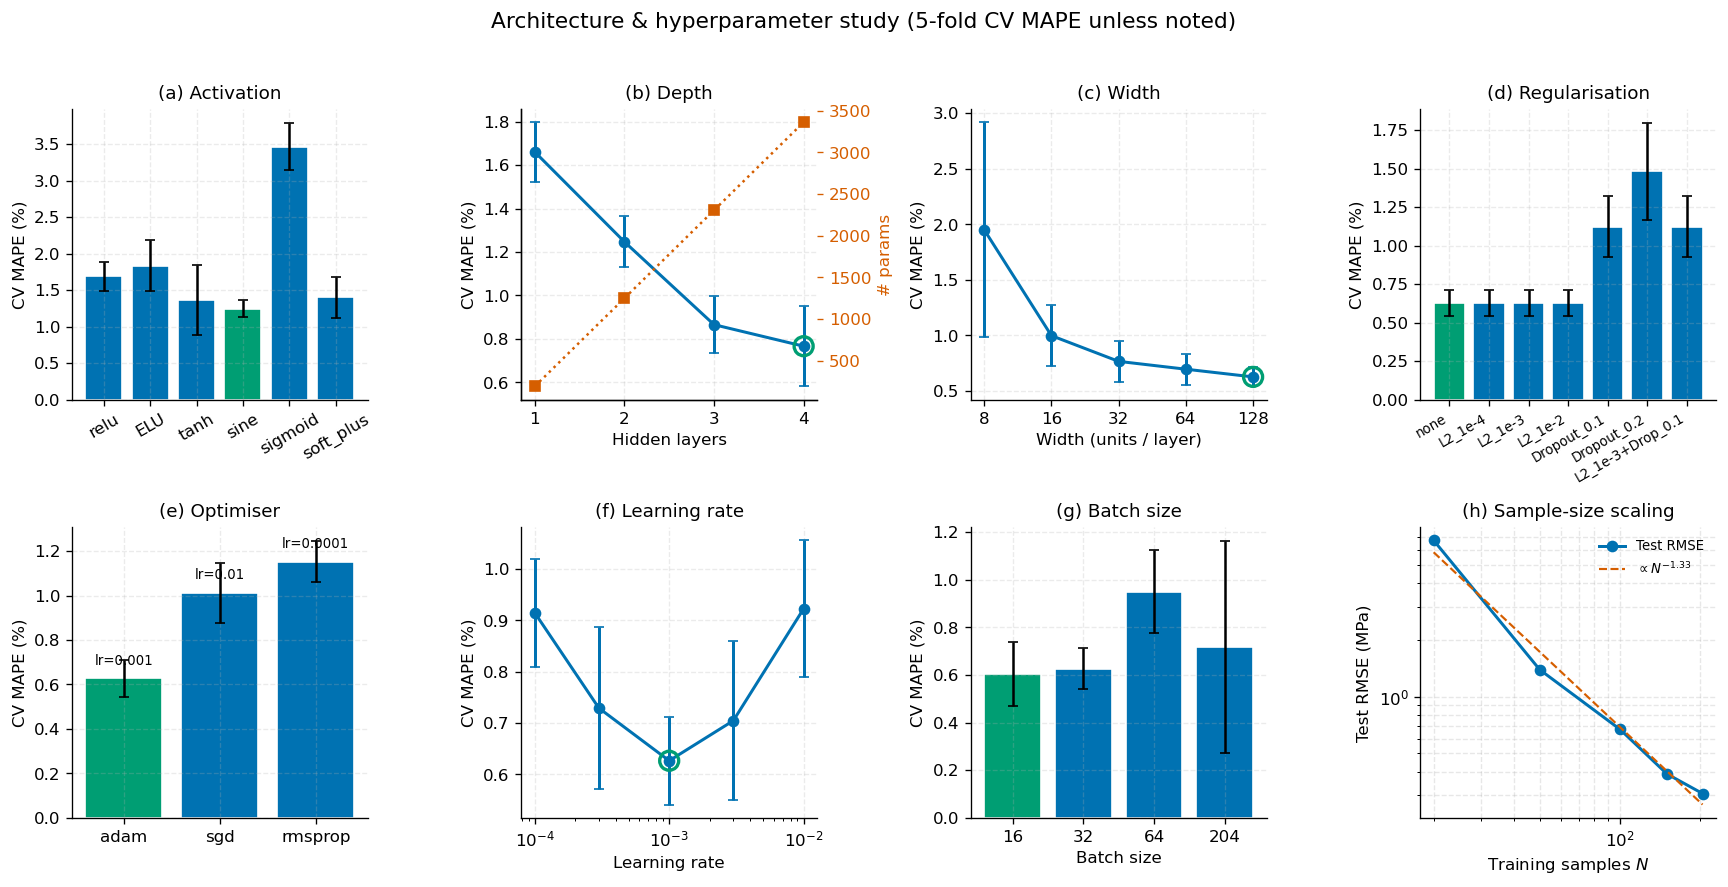

In [60]:
# ---- Figure: Hyperparameter study dashboard (all 8 experiments, one figure) ----
# Condenses the full architecture / hyperparameter search into a single report
# figure.  Each panel reads directly from the CSV the experiment saved, so the
# plot stays in sync with the actual metrics if the experiments are re-run.
exp1 = pd.read_csv('../results/exp1_activation.csv')
exp2 = pd.read_csv('../results/exp2_depth.csv')
exp3 = pd.read_csv('../results/exp3_width.csv')
exp4 = pd.read_csv('../results/exp4_regularisation.csv')
exp5 = pd.read_csv('../results/exp5_optimiser.csv')
exp6 = pd.read_csv('../results/exp6_lr.csv')
exp7 = pd.read_csv('../results/exp7_batch.csv')
exp8 = pd.read_csv('../results/exp8_n_samples.csv')

def _highlight_idx(values, best=min):
    """Return the integer index of the best (lowest/highest) row."""
    return int(np.argmin(values)) if best is min else int(np.argmax(values))

fig, axes = plt.subplots(2, 4, figsize=(14.5, 7.2))
fig.suptitle('Architecture & hyperparameter study (5-fold CV MAPE unless noted)',
             fontsize=13, y=1.02)

# --- Panel 1: Activation ---
ax = axes[0, 0]
idx = _highlight_idx(exp1['mape_mean'].values)
colors = [C_ACCENT if k == idx else C_PRIMARY for k in range(len(exp1))]
ax.bar(exp1['activation'], exp1['mape_mean'], yerr=exp1['mape_std'],
       color=colors, capsize=3, edgecolor='white')
ax.set_ylabel('CV MAPE (%)'); ax.set_title('(a) Activation')
ax.tick_params(axis='x', rotation=30)

# --- Panel 2: Depth (MAPE vs depth + params on twin axis) ---
ax = axes[0, 1]
ax.errorbar(exp2['depth'], exp2['mape_mean'], yerr=exp2['mape_std'],
            marker='o', color=C_PRIMARY, capsize=3, lw=1.8, label='MAPE')
ax2 = ax.twinx(); ax2.grid(False)
ax2.plot(exp2['depth'], exp2['n_params'], marker='s', ls=':',
         color=C_SECONDARY, label='# params')
ax2.set_ylabel('# params', color=C_SECONDARY)
ax2.tick_params(axis='y', colors=C_SECONDARY)
idx = _highlight_idx(exp2['mape_mean'].values)
ax.scatter([exp2['depth'].iloc[idx]], [exp2['mape_mean'].iloc[idx]],
           s=130, facecolor='none', edgecolor=C_ACCENT, lw=2, zorder=5)
ax.set_xlabel('Hidden layers'); ax.set_ylabel('CV MAPE (%)')
ax.set_title('(b) Depth'); ax.set_xticks(exp2['depth'])

# --- Panel 3: Width (log x) ---
ax = axes[0, 2]
ax.errorbar(exp3['width'], exp3['mape_mean'], yerr=exp3['mape_std'],
            marker='o', color=C_PRIMARY, capsize=3, lw=1.8)
idx = _highlight_idx(exp3['mape_mean'].values)
ax.scatter([exp3['width'].iloc[idx]], [exp3['mape_mean'].iloc[idx]],
           s=130, facecolor='none', edgecolor=C_ACCENT, lw=2, zorder=5)
ax.set_xscale('log', base=2)
ax.set_xlabel('Width (units / layer)'); ax.set_ylabel('CV MAPE (%)')
ax.set_title('(c) Width'); ax.set_xticks(exp3['width'])
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())

# --- Panel 4: Regularisation ---
ax = axes[0, 3]
idx = _highlight_idx(exp4['mape_mean'].values)
colors = [C_ACCENT if k == idx else C_PRIMARY for k in range(len(exp4))]
ax.bar(range(len(exp4)), exp4['mape_mean'], yerr=exp4['mape_std'],
       color=colors, capsize=3, edgecolor='white')
ax.set_xticks(range(len(exp4)))
ax.set_xticklabels(exp4['scheme'], rotation=30, ha='right', fontsize=8)
ax.set_ylabel('CV MAPE (%)'); ax.set_title('(d) Regularisation')

# --- Panel 5: Optimiser ---
ax = axes[1, 0]
idx = _highlight_idx(exp5['mape_mean'].values)
colors = [C_ACCENT if k == idx else C_PRIMARY for k in range(len(exp5))]
bars = ax.bar(exp5['optimiser'], exp5['mape_mean'], yerr=exp5['mape_std'],
              color=colors, capsize=3, edgecolor='white')
# Annotate each bar with its best learning rate
for rect, lr in zip(bars, exp5['best_lr']):
    ax.text(rect.get_x() + rect.get_width() / 2,
            rect.get_height() + 0.05,
            f'lr={lr:g}', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('CV MAPE (%)'); ax.set_title('(e) Optimiser')

# --- Panel 6: Learning rate (log x) ---
ax = axes[1, 1]
ax.errorbar(exp6['lr'], exp6['mape_mean'], yerr=exp6['mape_std'],
            marker='o', color=C_PRIMARY, capsize=3, lw=1.8)
idx = _highlight_idx(exp6['mape_mean'].values)
ax.scatter([exp6['lr'].iloc[idx]], [exp6['mape_mean'].iloc[idx]],
           s=130, facecolor='none', edgecolor=C_ACCENT, lw=2, zorder=5)
ax.set_xscale('log')
ax.set_xlabel('Learning rate'); ax.set_ylabel('CV MAPE (%)')
ax.set_title('(f) Learning rate')

# --- Panel 7: Batch size ---
ax = axes[1, 2]
idx = _highlight_idx(exp7['mape_mean'].values)
colors = [C_ACCENT if k == idx else C_PRIMARY for k in range(len(exp7))]
ax.bar([str(b) for b in exp7['batch_size']],
       exp7['mape_mean'], yerr=exp7['mape_std'],
       color=colors, capsize=3, edgecolor='white')
ax.set_xlabel('Batch size'); ax.set_ylabel('CV MAPE (%)')
ax.set_title('(g) Batch size')

# --- Panel 8: Training-set size (log-log scaling law) ---
ax = axes[1, 3]
n = exp8['n_samples'].values.astype(float)
rmse = exp8['test_rmse'].values.astype(float)
ax.loglog(n, rmse, marker='o', color=C_PRIMARY, lw=1.8, label='Test RMSE')
# Fit a power-law  RMSE = A * N^alpha
coef = np.polyfit(np.log(n), np.log(rmse), 1)
n_fit = np.linspace(n.min(), n.max(), 100)
ax.loglog(n_fit, np.exp(coef[1]) * n_fit ** coef[0],
          ls='--', color=C_SECONDARY, lw=1.3,
          label=fr'$\propto N^{{{coef[0]:.2f}}}$')
ax.set_xlabel('Training samples $N$')
ax.set_ylabel('Test RMSE (MPa)')
ax.set_title('(h) Sample-size scaling')
ax.legend(fontsize=8, loc='upper right')
ax.grid(which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig_hparam_dashboard.png')
plt.show()

#### 3D Loss Landscape

Two random directions $d_1, d_2$ are drawn in weight space and **filter-normalised** (Li et al. 2018) so each layer's perturbation has the same Frobenius norm as the corresponding trained tensor. Training loss is evaluated on a 31×31 grid of $(\alpha,\beta)$ with weights $\theta = \theta^{*} + \alpha\,d_1 + \beta\,d_2$. The bowl around the trained optimum shows how flat the basin is — flatter minima are associated with better generalisation.

In [ ]:
# ---- Figure: 3D loss landscape around the final NN optimum ----
# Filter-normalized random directions (Li et al. 2018) projected to 2D.
# For each (alpha, beta) grid point we perturb the trained weights by
#     theta = theta* + alpha*d1 + beta*d2
# and evaluate training loss. The bowl around the minimum tells us how flat
# the basin is - flat minima generalise better (Hochreiter & Schmidhuber 1997).
import copy
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3d projection)

# Snapshot trained weights so we can always restore them after perturbation
theta_star = copy.deepcopy(final_model.state_dict())

# Two random directions with the same structure as the parameter tensors.
# Filter-normalise: each tensor's random direction is rescaled so its
# Frobenius norm matches the corresponding trained tensor's norm.
torch.manual_seed(SEED)
d1, d2 = {}, {}
for name, tensor in theta_star.items():
    r1 = torch.randn_like(tensor)
    r2 = torch.randn_like(tensor)
    scale = tensor.norm() / (r1.norm() + 1e-10)
    r1 = r1 * scale
    r2 = r2 * (tensor.norm() / (r2.norm() + 1e-10))
    d1[name] = r1
    d2[name] = r2

# Evaluate training loss at each grid point
X_loss_t = torch.tensor(X_sub_s, dtype=torch.float32)
y_loss_t = torch.tensor(y_sub_s, dtype=torch.float32).view(-1, 1)
loss_fn = nn.MSELoss()

GRID = 41
ALPHA = np.linspace(-4, 4, GRID)
BETA = np.linspace(-4, 4, GRID)
A, B = np.meshgrid(ALPHA, BETA)
L = np.zeros_like(A)

final_model.eval()
with torch.no_grad():
    for i in range(GRID):
        for j in range(GRID):
            a, b = float(A[i, j]), float(B[i, j])
            perturbed = {k: theta_star[k] + a * d1[k] + b * d2[k]
                         for k in theta_star}
            final_model.load_state_dict(perturbed)
            L[i, j] = loss_fn(final_model(X_loss_t), y_loss_t).item()

# Restore the original (trained) weights so downstream cells see best model
final_model.load_state_dict(theta_star)

# Loss can span orders of magnitude away from the optimum - log scale is cleaner
L_log = np.log10(L)
min_i, min_j = np.unravel_index(np.argmin(L), L.shape)

# ---- 3D surface + contour companion plot ----
fig = plt.figure(figsize=(12.8, 5.6))
ax3d = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax3d.plot_surface(A, B, L_log, cmap='viridis',
                         linewidth=0, antialiased=True,
                         alpha=0.92, rstride=1, cstride=1,
                         edgecolor='none')
# Marker on the trained optimum (and a stem down to the base for clarity)
ax3d.scatter([A[min_i, min_j]], [B[min_i, min_j]],
             [L_log[min_i, min_j]], color=C_ACCENT, s=70,
             edgecolor='white', linewidth=1.3, label=r'Trained $\theta^{*}$')
ax3d.plot([A[min_i, min_j]] * 2, [B[min_i, min_j]] * 2,
          [L_log.min(), L_log[min_i, min_j]],
          color=C_ACCENT, ls=':', lw=1)
ax3d.set_xlabel(r'$\alpha$ (direction 1)')
ax3d.set_ylabel(r'$\beta$ (direction 2)')
ax3d.set_zlabel(r'$\log_{10}$ MSE (scaled)')
ax3d.set_title('Loss landscape surface')
ax3d.view_init(elev=28, azim=135)
ax3d.legend(loc='upper left', fontsize=9)

ax2d = fig.add_subplot(1, 2, 2)
cf = ax2d.contourf(A, B, L_log, levels=25, cmap='viridis')
cl = ax2d.contour(A, B, L_log, levels=12, colors='white',
                  linewidths=0.5, alpha=0.6)
ax2d.clabel(cl, inline=True, fontsize=7, fmt='%.1f')
ax2d.scatter([A[min_i, min_j]], [B[min_i, min_j]],
             color=C_ACCENT, s=110, edgecolor='white', linewidth=1.3,
             label=r'Trained $\theta^{*}$', zorder=5)
ax2d.set_xlabel(r'$\alpha$'); ax2d.set_ylabel(r'$\beta$')
ax2d.set_title('Log-loss contours')
ax2d.set_aspect('equal')
ax2d.legend(loc='lower right', fontsize=9)
cb = fig.colorbar(cf, ax=ax2d, shrink=0.9, pad=0.04)
cb.set_label(r'$\log_{10}$ MSE (scaled)')

fig.suptitle('Filter-normalised 2D projection of the NN training-loss landscape',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/fig_loss_landscape.png')
plt.show()

## Comparison with GPR Baseline

Side-by-side comparison of the best NN against the best GPR model (Matern 2.5 kernel) on the same held-out test set. Metrics: Test RMSE, MAE, MAPE, training time, prediction time.

Metric                         GPR          NN       delta
----------------------------------------------------------
Test RMSE (MPa)             0.1616      0.3065     +0.1449
Test MAE (MPa)              0.1273      0.2029     +0.0756
Test MAPE (%)               0.2581      0.4177     +0.1596
Test R^2                    0.9998      0.9994     -0.0005


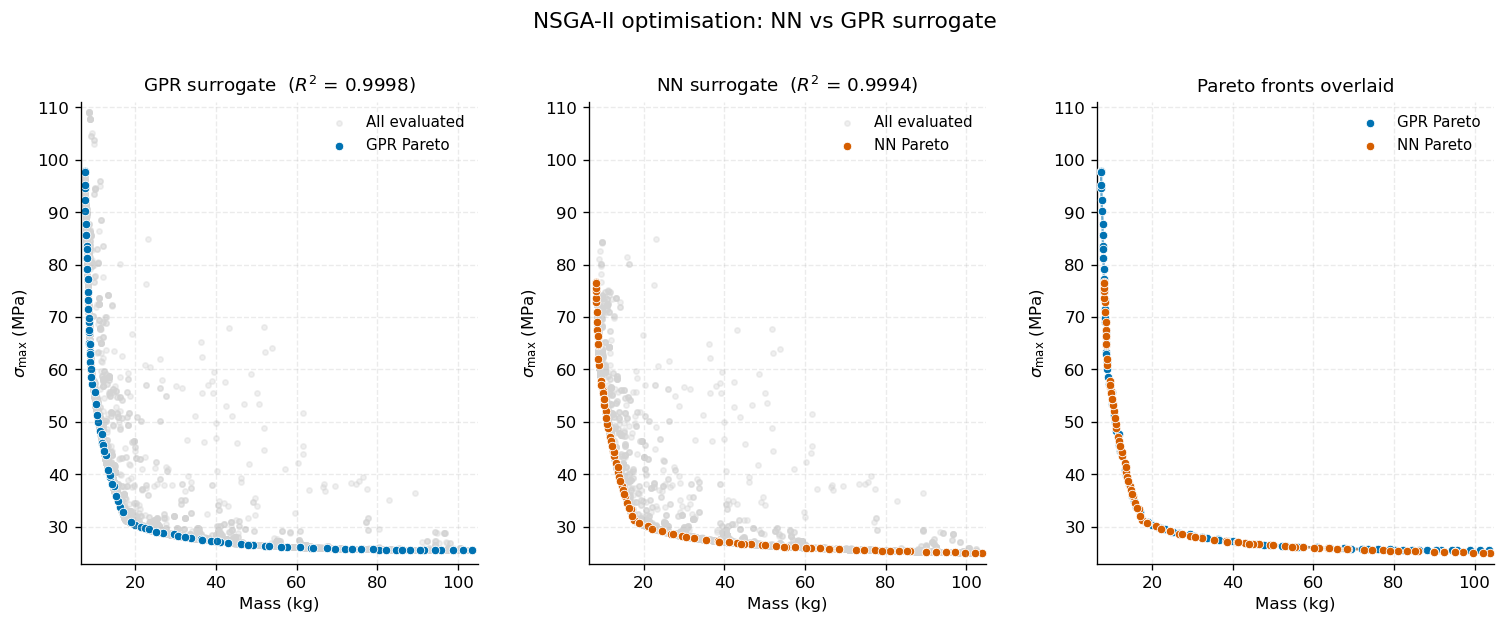

In [64]:
# ---- Side-by-side comparison: NN vs GPR surrogate ----
# Both Pareto fronts are produced by the two optimisation scripts:
#     src/MaintenancePlate_Optimisation.py       (GPR)
#     src/MaintenancePlate_Optimisation_NN.py    (NN)
# which save their fronts to models/pareto_front_{gpr,nn}.csv.
models_dir = Path('../models')
results_dir = Path('../results')
pf_gpr = pd.read_csv(results_dir / 'pareto_front_gpr.csv')
pa_gpr = pd.read_csv(results_dir / 'pareto_all_gpr.csv')
pf_nn = pd.read_csv(results_dir / 'pareto_front_nn.csv')
pa_nn = pd.read_csv(results_dir / 'pareto_all_nn.csv')

# ---- Re-evaluate GPR on the same held-out test set used for the NN ----
gpr_pipeline = joblib.load(models_dir / 'gpr_best_pipeline.pkl')
y_pred_gpr = gpr_pipeline.predict(X_test_raw)
err_gpr = y_pred_gpr - y_test_raw
rmse_gpr = float(np.sqrt(np.mean(err_gpr ** 2)))
mae_gpr = float(np.mean(np.abs(err_gpr)))
mape_gpr = float(np.mean(np.abs(err_gpr / y_test_raw)) * 100)
r2_gpr = 1.0 - float(
    np.sum(err_gpr ** 2) / np.sum((y_test_raw - y_test_raw.mean()) ** 2))

# Pretty comparison table (matches the format in the final_metrics CSV)
print(f"{'Metric':<22s}{'GPR':>12s}{'NN':>12s}{'delta':>12s}")
print('-' * 58)
for name, g, n in [
    ('Test RMSE (MPa)', rmse_gpr, test_metrics['rmse']),
    ('Test MAE (MPa)', mae_gpr, test_metrics['mae']),
    ('Test MAPE (%)', mape_gpr, test_metrics['mape']),
    ('Test R^2', r2_gpr, test_metrics['r2']),
]:
    delta = n - g
    print(f"{name:<22s}{g:>12.4f}{n:>12.4f}{delta:>+12.4f}")

# ---- Side-by-side figure: three panels with shared axes ----
xlim = (min(pa_gpr.mass_kg.min(), pa_nn.mass_kg.min()) - 1,
        max(pa_gpr.mass_kg.max(), pa_nn.mass_kg.max()) + 1)
ylim = (min(pa_gpr.stress_mpa.min(), pa_nn.stress_mpa.min()) - 2,
        max(pa_gpr.stress_mpa.max(), pa_nn.stress_mpa.max()) + 2)

fig, axes = plt.subplots(1, 3, figsize=(15.2, 5.0),
                         gridspec_kw={'wspace': 0.28})

# GPR panel
axes[0].scatter(pa_gpr.mass_kg, pa_gpr.stress_mpa, c='lightgray',
                alpha=0.35, s=10, label='All evaluated')
axes[0].scatter(pf_gpr.mass_kg, pf_gpr.stress_mpa, c=C_PRIMARY,
                s=26, edgecolor='white', linewidth=0.5, label='GPR Pareto')
axes[0].set_xlabel('Mass (kg)')
axes[0].set_ylabel(r'$\sigma_{\max}$ (MPa)')
axes[0].set_title(f'GPR surrogate  ($R^2$ = {r2_gpr:.4f})')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_xlim(xlim); axes[0].set_ylim(ylim)

# NN panel
axes[1].scatter(pa_nn.mass_kg, pa_nn.stress_mpa, c='lightgray',
                alpha=0.35, s=10, label='All evaluated')
axes[1].scatter(pf_nn.mass_kg, pf_nn.stress_mpa, c=C_SECONDARY,
                s=26, edgecolor='white', linewidth=0.5, label='NN Pareto')
axes[1].set_xlabel('Mass (kg)')
axes[1].set_ylabel(r'$\sigma_{\max}$ (MPa)')
axes[1].set_title(f"NN surrogate  ($R^2$ = {test_metrics['r2']:.4f})")
axes[1].legend(loc='upper right', fontsize=9)
axes[1].set_xlim(xlim); axes[1].set_ylim(ylim)

# Overlay panel (sorted by mass to draw clean connecting lines)
gpr_s = pf_gpr.sort_values('mass_kg')
nn_s = pf_nn.sort_values('mass_kg')
axes[2].plot(gpr_s.mass_kg, gpr_s.stress_mpa, color=C_PRIMARY, lw=1.4,
             alpha=0.6, zorder=2)
axes[2].scatter(pf_gpr.mass_kg, pf_gpr.stress_mpa, c=C_PRIMARY,
                s=26, edgecolor='white', linewidth=0.5, label='GPR Pareto',
                zorder=3)
axes[2].plot(nn_s.mass_kg, nn_s.stress_mpa, color=C_SECONDARY, lw=1.4,
             alpha=0.6, zorder=2)
axes[2].scatter(pf_nn.mass_kg, pf_nn.stress_mpa, c=C_SECONDARY,
                s=26, edgecolor='white', linewidth=0.5, label='NN Pareto',
                zorder=3)
axes[2].set_xlabel('Mass (kg)')
axes[2].set_ylabel(r'$\sigma_{\max}$ (MPa)')
axes[2].set_title('Pareto fronts overlaid')
axes[2].legend(loc='upper right', fontsize=9)
axes[2].set_xlim(xlim); axes[2].set_ylim(ylim)

fig.suptitle('NSGA-II optimisation: NN vs GPR surrogate',
             fontsize=13, y=1.03)
plt.savefig('../figures/fig_pareto_comparison.png', bbox_inches='tight')
plt.show()